**All genes (Y), early-stopping (Y)**

In [1]:
import sys
import os

# Get the directory containing the notebook
NOTEBOOK_DIR = os.getcwd()

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [3]:
from src.data.umi_data import UMIVaeDataset
from src.celluntangler import utils
from src.celluntangler.models import Trainer
from src.celluntangler.models.nb_vae import NBVAE
from src.visualization.helpers import split_embeddings
from src.visualization.visualization_functions import visualize_poincare_from_lorentz, visualize_embedding, visualize_2d

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from src.paths.paths import ALL_CELLS_PATH 

In [5]:
# TODO - change path to actual data you care about
# TODO - debug getting HVG genes working with annotated dataframe
adata = sc.read_h5ad("../../../data/HGSOC/ALL_CELLS/all_cells_1p.h5ad")

In [6]:
adata 

AnnData object with n_obs × n_vars = 10199 × 31815
    obs: 'percent.mt', 'percent.rb', 'doublet', 'author_sample_id', 'S.Score', 'G2M.Score', 'Phase', 'CC.Diff', 'author_cell_type', 'nCount_RNA', 'nFeature_RNA', 'doublet_score', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'author_tumor_supersite', 'author_tumor_site', 'author_tumor_subsite', 'author_sort_parameters', 'author_therapy', 'author_procedure', 'author_procedure_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'author_cell_type_colors', 'citation', 'default_embedding', 'neighbors', 'organ

In [7]:
# Get unnormalized gene expression reads
# REQUIREbMENT: CellUntangler requires gene-expression counts
adata = adata.raw.to_adata()

### Pre-processing

In [8]:
adata.var["gene_symbols"] = adata.var["feature_name"]

In [9]:
dissociation_genes_path = "../../../genes/HGSOC/multi_signal/jiarui_12_2025/human_cell_dissociation_genes.tsv" 

dissociation_genes = pd.read_csv(dissociation_genes_path, header = None, sep = "\t")

In [10]:
## Brief Analysis of Number of Relevant Genes Found 

In [11]:
dissociation_genes_set = set(dissociation_genes.iloc[:,0])

In [12]:
contained_genes_dissociation = adata.var["gene_symbols"].isin(dissociation_genes[0])

In [13]:
print(f"Number of cell dissociation genes present in adata: {np.sum(contained_genes_dissociation)}")

Number of cell dissociation genes present in adata: 32


### Pre-processing x2 - Calculating Gene-Enrichment Scores 

In [14]:
from anndata.utils import make_index_unique

# 1. Get the gene symbols and convert to a standard pandas Index
temp_index = pd.Index(adata.var['gene_symbols'].astype(str))

# 2. Use the anndata utility to make the index unique (appends -1, -2, etc. to duplicates)
adata.var_names = make_index_unique(temp_index)
adata.var_names.name = None
adata.raw = adata ### FIX!!!

In [15]:
interferon_genes_path = "../../../genes/HGSOC/multi_signal/jiarui_12_2025/human_interferon_genes.tsv" 
interferon_genes = pd.read_csv(interferon_genes_path, header = None, sep="\t") # PROGRESS!!!
interferon_genes_set = set(interferon_genes.iloc[:,0]) 

In [16]:
sc.tl.score_genes(
    adata,
    gene_list=interferon_genes_set,
    score_name="interferon_score"
)


sc.tl.score_genes(
    adata,
    gene_list=dissociation_genes_set,
    score_name="dissociation_score"
)

#### Re-order Genes

In [17]:
# Order Genes in adata such that genes appear in following order: cell cycle genes, interferon genes, dissociation genes
dissociation_indices = np.where(contained_genes_dissociation)[0]

all_known_indices = np.hstack((dissociation_indices))
remaining_indices = np.setdiff1d(np.arange(adata.shape[1]), all_known_indices)

rearranged_indices = np.hstack((dissociation_indices, remaining_indices))
rearranged_indices = rearranged_indices.astype(int)

In [18]:
adata = adata[:, rearranged_indices] # .copy() is safer in AnnData
adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_6710/1082852305.py:2: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!


### Model Configuration

In [19]:
model_name = "e2, e10"

In [20]:
from src.celluntangler.models.get_config import get_config
config = get_config()
config.model_name = model_name
config.seed = 68715
config.init = "custom"
config.max_epochs = 500 
config.epochs = 500

In [21]:
if config.seed:  
    torch.manual_seed(config.seed)
    np.random.seed(config.seed) 
    np.random.default_rng(config.seed)
components = utils.parse_components(model_name, config.fixed_curvature) 

### Creating Training Dataset

In [22]:
if not "batch" in adata.obs.columns.tolist(): 
    adata.obs["batch"] = adata.obs.index.str.split("_").str[0]
    adata.obs["batch"] = adata.obs["batch"].astype("category")

In [23]:
batch = adata.obs.batch.cat.codes.values 
batch = batch[:,None]
batch = batch.astype(np.int64) 

In [24]:
# One entry in n_batch for each "factor of batch effects"
config.n_batch = [ len(np.unique(batch)) ]

In [25]:
batch_counts = np.bincount(batch[:,0])
batch_counts = batch_counts[1:]

In [26]:
# Creating Training Dataset
x = adata.X.todense().astype(np.double)

In [27]:
# y holds the batch vector for the dataset
y = batch 
in_dim = x.shape[1]
print(f"in_dim = {in_dim}")
batch_size = config.batch_size
dataset = UMIVaeDataset(batch_size=batch_size, in_dim=in_dim)
print(f"dataset.in_dim = {dataset.in_dim}")
# Create the dataset loaders
train_loader = dataset.create_loaders(x, y, seed=config.seed)

in_dim = 31815
dataset.in_dim = 31815
Dataset seed: 68715


In [28]:
# Creating (Disjoint) Masks
mask_dissociation = np.zeros(adata.n_vars) 
mask_dissociation[adata.var["gene_symbols"].isin(dissociation_genes[0])] = 1

mask_all = np.ones(adata.n_vars)
mask_all[adata.var["gene_symbols"].isin(dissociation_genes[0])] = 0 

mask = torch.tensor([mask_dissociation, mask_all])

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_6710/4212362242.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  mask = torch.tensor([mask_dissociation, mask_all])


### Configure Save Paths

In [29]:
epoch_embeddings_save_path = "../../../results/multi_subspace/all_cells/01_13_signal_degradation_check_dissociation/all_genes_y_es_y"

In [30]:
visualize_information={}
# The epochs to save the intermediate embeddings for
visualize_information["epochs"]=[i for i in range(0, 500, 50)] 
visualize_information["x"]=x
visualize_information["y"]=y
visualize_information["embeddings_save_path"]=epoch_embeddings_save_path
visualize_information["model_name"]=config.model_name
visualize_information["device"]=config.device

### Model Creation

In [31]:
use_gpu = False
if use_gpu:
  print("Using GPU")
  config.device = torch.device("cuda")
else:
  print("Using CPU")
  config.device = torch.device("cpu")

Using CPU


In [32]:
torch.set_default_dtype(torch.float64)

In [33]:
model = NBVAE(h_dim=config.h_dim,
              components=components,
              mask=mask,
              dataset=dataset,
              config=config).to(config.device)

Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
EuclideanComponent(R^2)


### Training

In [34]:
trainer = Trainer(model)

optimizer = trainer.build_optimizer(learning_rate=config.learning_rate,
                                        fixed_curvature=config.fixed_curvature,
                                        use_adamw=config.use_adamw,
                                        weight_decay=config.weight_decay)

betas = utils.linear_betas(config.start,
                           config.end,
                           end_epoch=config.end_epoch,
                           epochs=config.epochs)


trainer.train_epochs(optimizer=optimizer,
                       train_data=train_loader,
                       betas=betas,
                       likelihood_n=0,
                       max_epochs=config.max_epochs,
                       visualize_information=visualize_information)

initialized early stopper
	TrainEpoch 0:	

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


{'bce': -9987.125, 'kl': 150.265, 'elbo': -10137.391, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_e2/curvature': 0.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 1:	{'bce': -7614.662, 'kl': 40.635, 'elbo': -7655.297, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_e2/curvature': 0.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 2:	{'bce': -7513.89, 'kl': 30.586, 'elbo': -7544.476, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_e2/curvature': 0.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 3:	{'bce': -7480.023, 'kl': 27.27, 'elbo': -7507.293, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_e2/curvature': 0.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 4:	{'bce': -7383.079, 'kl': 29.946, 'elbo': -7413.024, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_e2/curvature': 0.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 5:	{'bce': -7273.573, 'kl': 29.663, 'elbo': -7303.236, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1

### Saving Embeddings

In [36]:
embeddings_save_path = epoch_embeddings_save_path

In [37]:
checkpoint = torch.load(
    os.path.join(embeddings_save_path,  f"{model_name}_best_model.pt"),
    map_location=config.device
)
model.load_state_dict(checkpoint["model_state"])
model.eval()

NBVAE(
  (components): ModuleList(
    (0): EuclideanComponent(R^2)
    (1): EuclideanComponent(R^10)
  )
  (encoder): Sequential(
    (0): Linear(in_features=31815, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): GELU(approximate='none')
  )
  (decoder): Sequential(
    (0): Linear(in_features=53, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): GELU(approximate='none')
  )
  (fc_mu): Linear(in_features=128, out_features=31815, bias=True)
  (fc_sigma): Linear(in_features=128, out_features=31815, bias=True)
)

In [38]:
a = model(torch.log1p(torch.tensor(x, device=config.device)), torch.tensor(y, device=config.device))
np.savetxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params_best.txt'), a[4].detach().to(torch.device("cpu")).numpy())

### Analysis

In [38]:
gene_expression_matrix_path = epoch_embeddings_save_path

In [39]:
embeddings = np.loadtxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params_best.txt'))
component_embeddings = split_embeddings(model_name, embeddings)
for c in component_embeddings:
    adata.obsm[c] = component_embeddings[c]

e2 2
e10 10


#### Visualization of Component 1 (R2)

##### Visualization fo Cell Cycle Signals

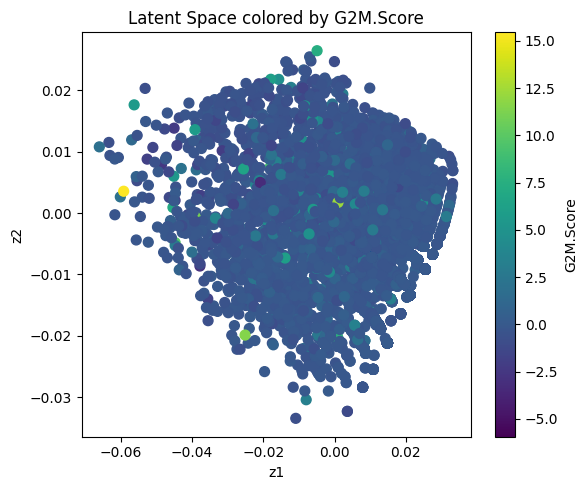

In [37]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component1_e2"
desired_obs = 'G2M.Score'

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation=desired_obs
)

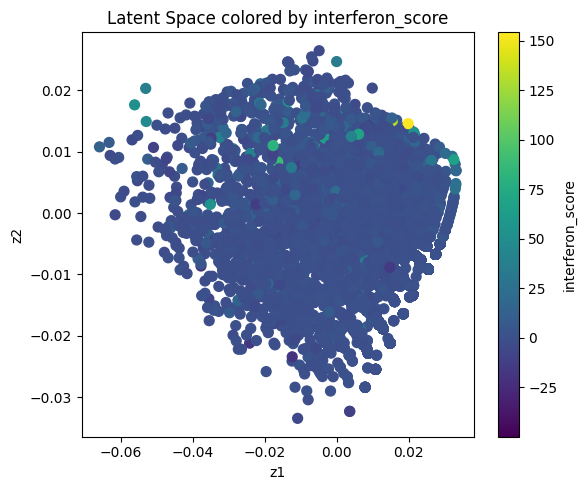

In [38]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component1_e2"
desired_obs = 'interferon_score'

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation=desired_obs
)

In [1]:
ax = adata.obs["interferon_score"].hist()
ax.set_title("Interferon Score Distribution")

NameError: name 'adata' is not defined

Text(0.5, 1.0, 'Dissociation Score Distribution')

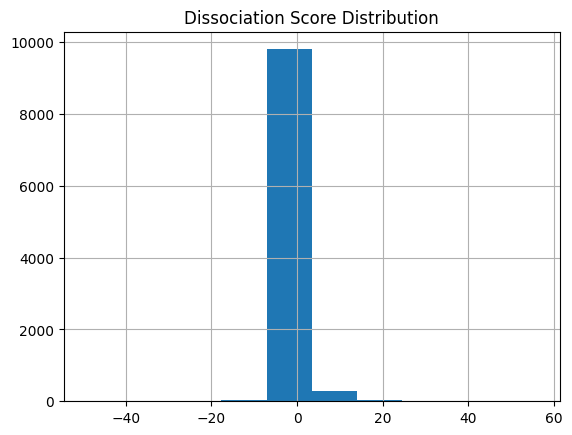

In [41]:
ax = adata.obs["dissociation_score"].hist()
ax.set_title("Dissociation Score Distribution")

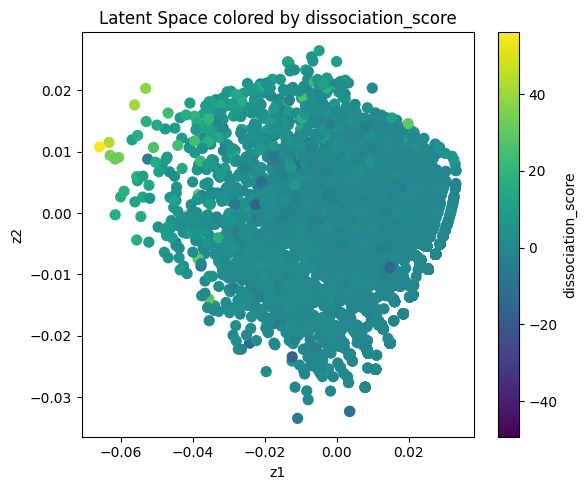

In [47]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component1_e2"
desired_obs = 'dissociation_score'

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation=desired_obs
)

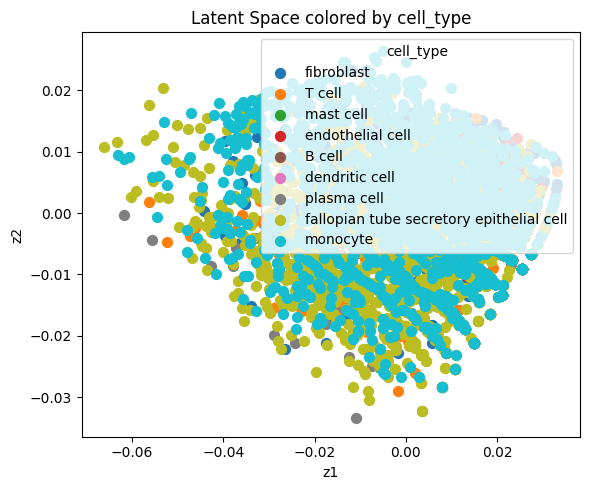

In [39]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component1_e2"
desired_obs = 'cell_type'

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation=desired_obs,
    cmap="tab10",
    show_legend = True
)

#### Visualization of Component 4 (E10)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


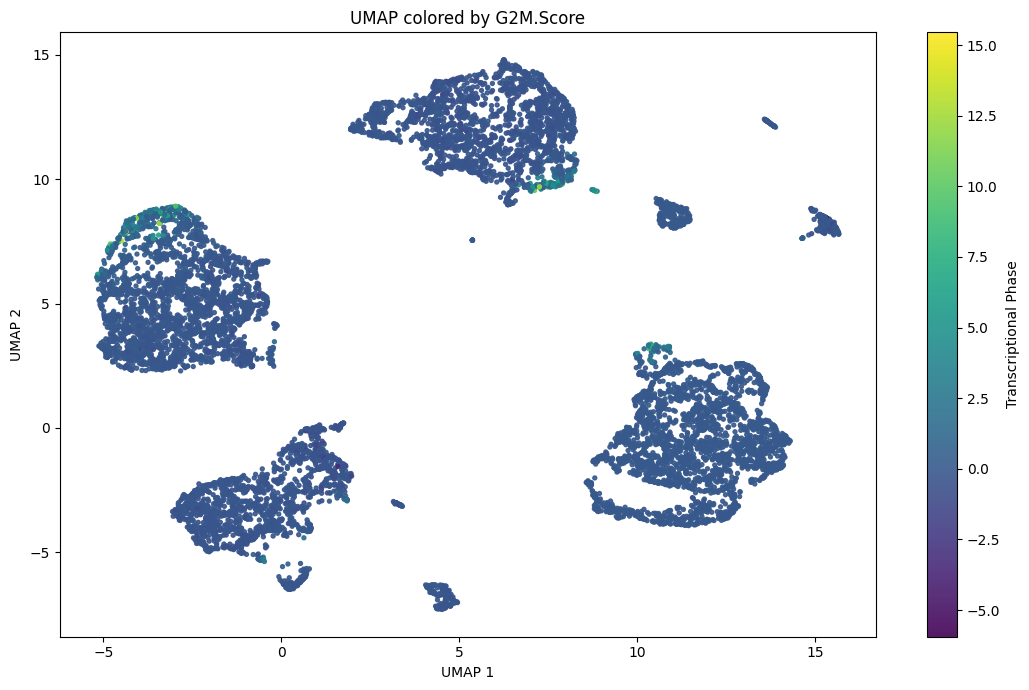

In [40]:
# TODO - add custom UMAP code that doesn't hang! 
# Visualize UMAP using cell cycle ground truth, cell type ground truth, other labels, .... 
# TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'G2M.Score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase",
)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


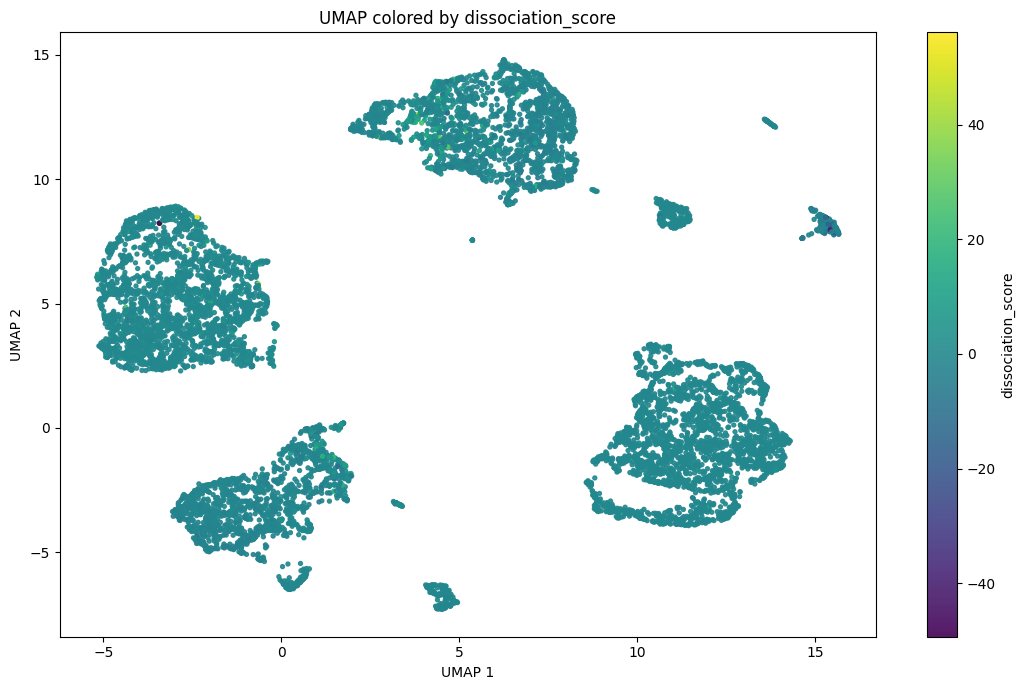

In [41]:
embeddings_key = "component2_e10"
desired_obs = 'dissociation_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


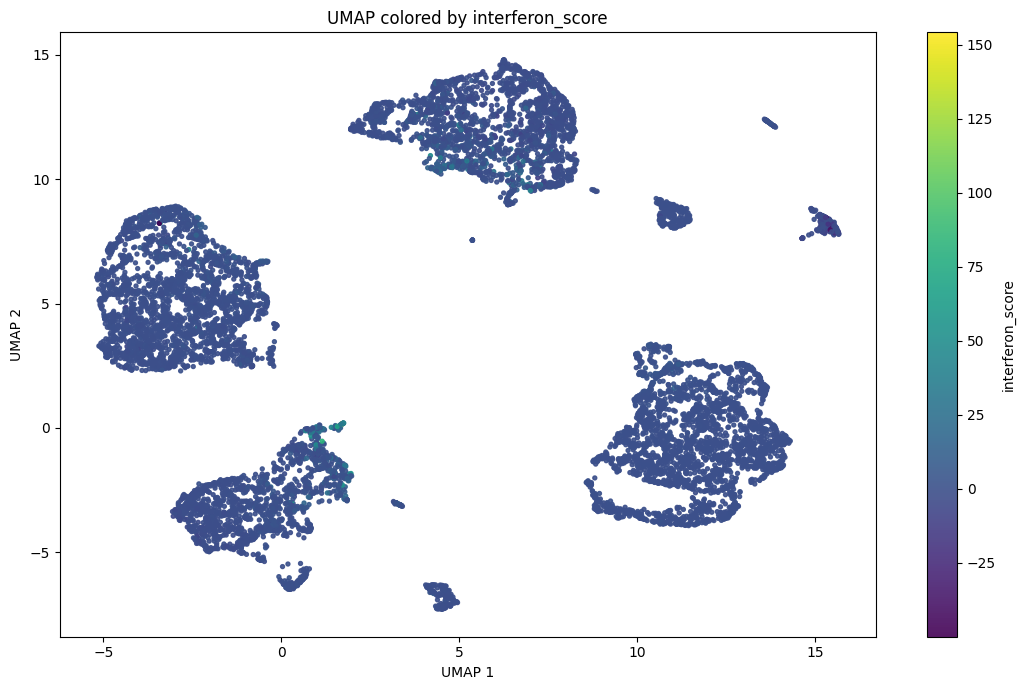

In [42]:
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
)

In [43]:
import pandas as pd

# define consistent coloring for cell_types
cell_types = pd.Categorical(adata.obs["cell_type"])
categories = cell_types.categories

# Use tab20
base_cmap = plt.get_cmap("tab20")

# Ensure one-to-one mapping, repeat if >20
cat_colors = {}
for i, cat in enumerate(categories):
    cat_colors[cat] = base_cmap(i % 20)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


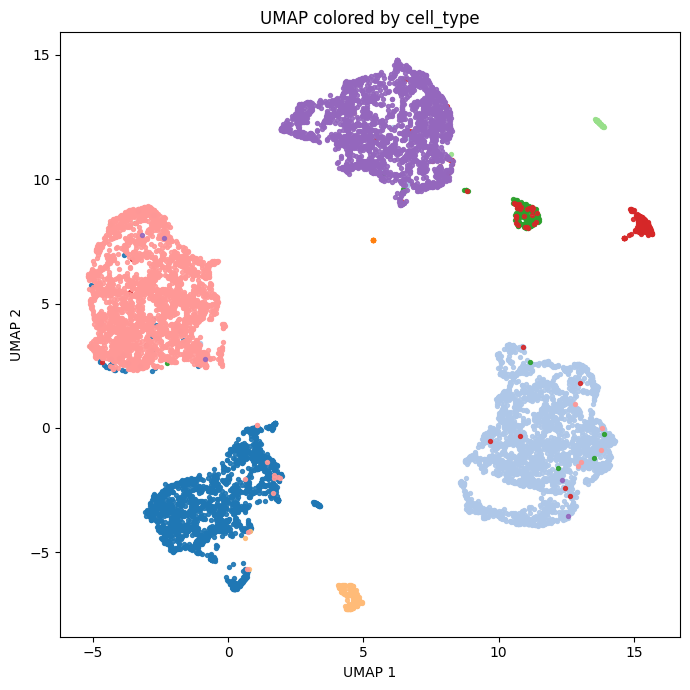

In [44]:
embeddings_key = "component2_e10"
desired_obs = 'cell_type'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cat_colors=cat_colors,   # <--- pass the fixed mapping
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)

In [39]:
adata.obsm[embeddings_key]

array([[-0.15051945,  1.52000961, -0.52237633, ...,  0.42655587,
         0.51343066,  0.93561279],
       [ 0.99898784, -1.62509   , -0.49851304, ...,  0.83688779,
         0.48993682,  0.84032716],
       [-1.32811466,  0.72807986, -0.42512381, ..., -0.0040537 ,
         0.41140037,  0.36675999],
       ...,
       [ 1.0607357 , -0.48812373, -0.34254143, ...,  0.754531  ,
         0.35304827,  0.24795779],
       [-0.39048786,  0.8907987 , -0.33398802, ..., -0.27405781,
         0.3405385 ,  0.53354324],
       [-0.874829  ,  0.74302488, -0.44546643, ..., -0.34218657,
         0.44383728,  0.70908793]])

In [40]:
adata.obsm[embeddings_key].shape

(10199, 10)

#### Initial Attempts at Understanding the 10-Dimensional Manifold Through PCA

In [48]:
from sklearn.decomposition import PCA

Z = adata.obsm[embeddings_key]   # shape (n_cells, 10)

max_k = Z.shape[1]   # = 10
recon_errors = []
var_explained = []

for k in range(1, max_k + 1):
    pca = PCA(n_components=k)
    Z_k = pca.fit_transform(Z)
    Z_recon = pca.inverse_transform(Z_k)

    # Mean squared reconstruction error
    mse = np.mean((Z - Z_recon) ** 2)
    recon_errors.append(mse)

    var_explained.append(np.sum(pca.explained_variance_ratio_))


In [49]:
elbow_df = pd.DataFrame({
    "n_components": np.arange(1, max_k + 1),
    "reconstruction_MSE": recon_errors,
    "cumulative_variance": var_explained
})

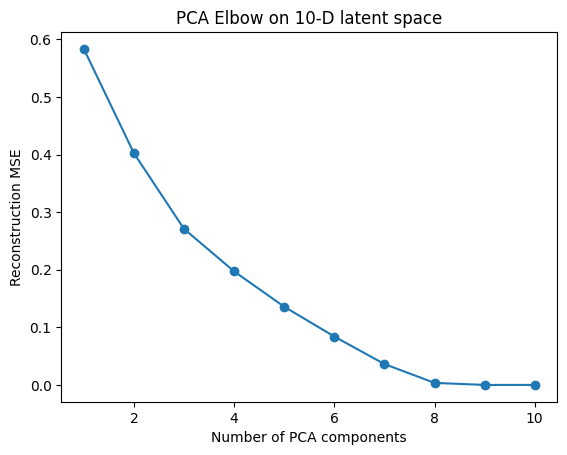

In [50]:
plt.plot(elbow_df["n_components"], elbow_df["reconstruction_MSE"], marker="o")
plt.xlabel("Number of PCA components")
plt.ylabel("Reconstruction MSE")
plt.title("PCA Elbow on 10-D latent space")
plt.show()

In [51]:
from kneed import KneeLocator

kneedle = KneeLocator(
    elbow_df["n_components"],
    elbow_df["reconstruction_MSE"],
    curve="convex",
    direction="decreasing"
)

optimal_k = kneedle.elbow
optimal_k


4

#### Choose the `n_components` for PCA

In [52]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

Z = adata.obsm[embeddings_key]   # shape (n_cells, 10)

# Run PCA
pca = PCA(n_components=optimal_k)
Z_pca = pca.fit_transform(Z)

# Store PCs back in AnnData
adata.obsm["X_e10_pca"] = Z_pca

# Variance explained
var_exp = pca.explained_variance_ratio_
cum_var = np.cumsum(var_exp)

pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(optimal_k)],
    "Variance_explained": var_exp,
    "Cumulative": cum_var
})


,PC,Variance_explained,Cumulative
0,PC1,0.371109,0.371109
1,PC2,0.195222,0.566332
2,PC3,0.141649,0.707980
3,PC4,0.079461,0.787442


In [54]:
adata.obs["latent_PC1"] = Z_pca[:,0]
adata.obs["latent_PC2"] = Z_pca[:,1]
adata.obs["latent_PC3"] = Z_pca[:,2]
adata.obs["latent_PC4"] = Z_pca[:,3]

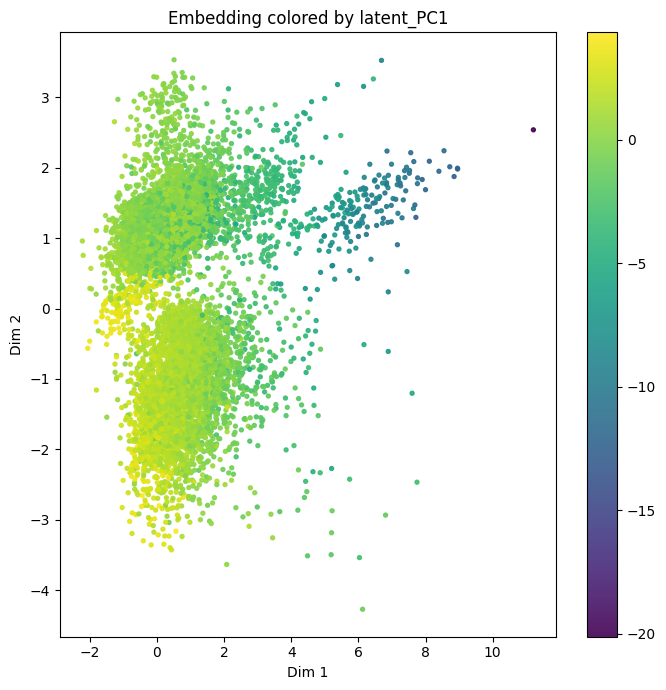

In [55]:
embeddings_key = "component4_e10"
desired_obs = 'latent_PC1'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cat_colors=cat_colors,   # <--- pass the fixed mapping
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)

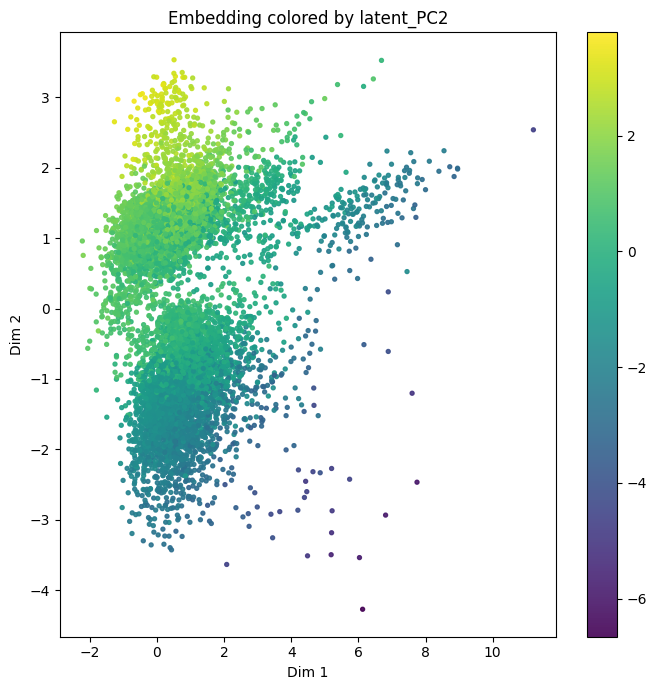

In [53]:
embeddings_key = "component4_e10"
desired_obs = 'latent_PC2'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cat_colors=cat_colors,   # <--- pass the fixed mapping
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)

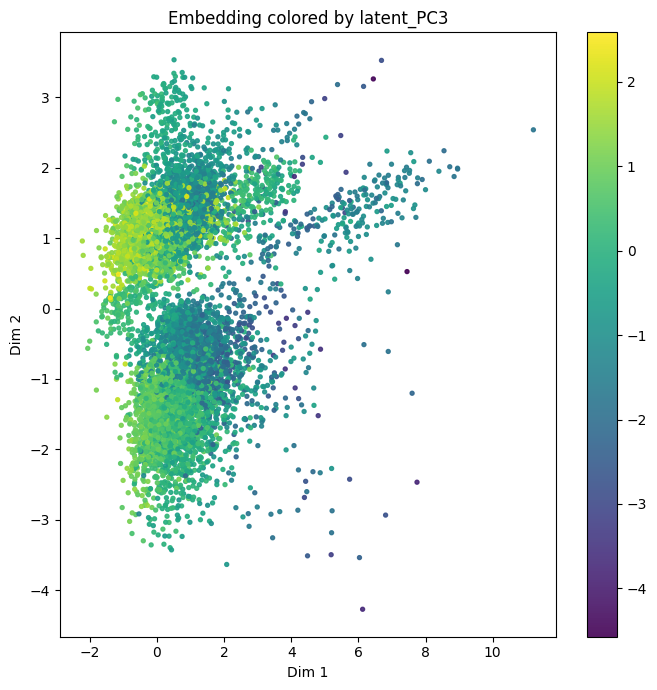

In [54]:
embeddings_key = "component4_e10"
desired_obs = 'latent_PC3'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cat_colors=cat_colors,   # <--- pass the fixed mapping
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)

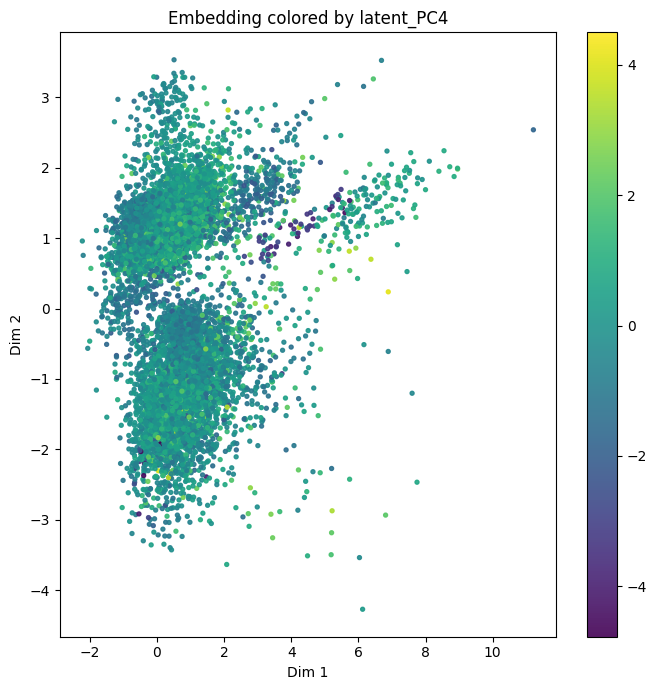

In [55]:
embeddings_key = "component4_e10"
desired_obs = 'latent_PC4'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cat_colors=cat_colors,   # <--- pass the fixed mapping
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)

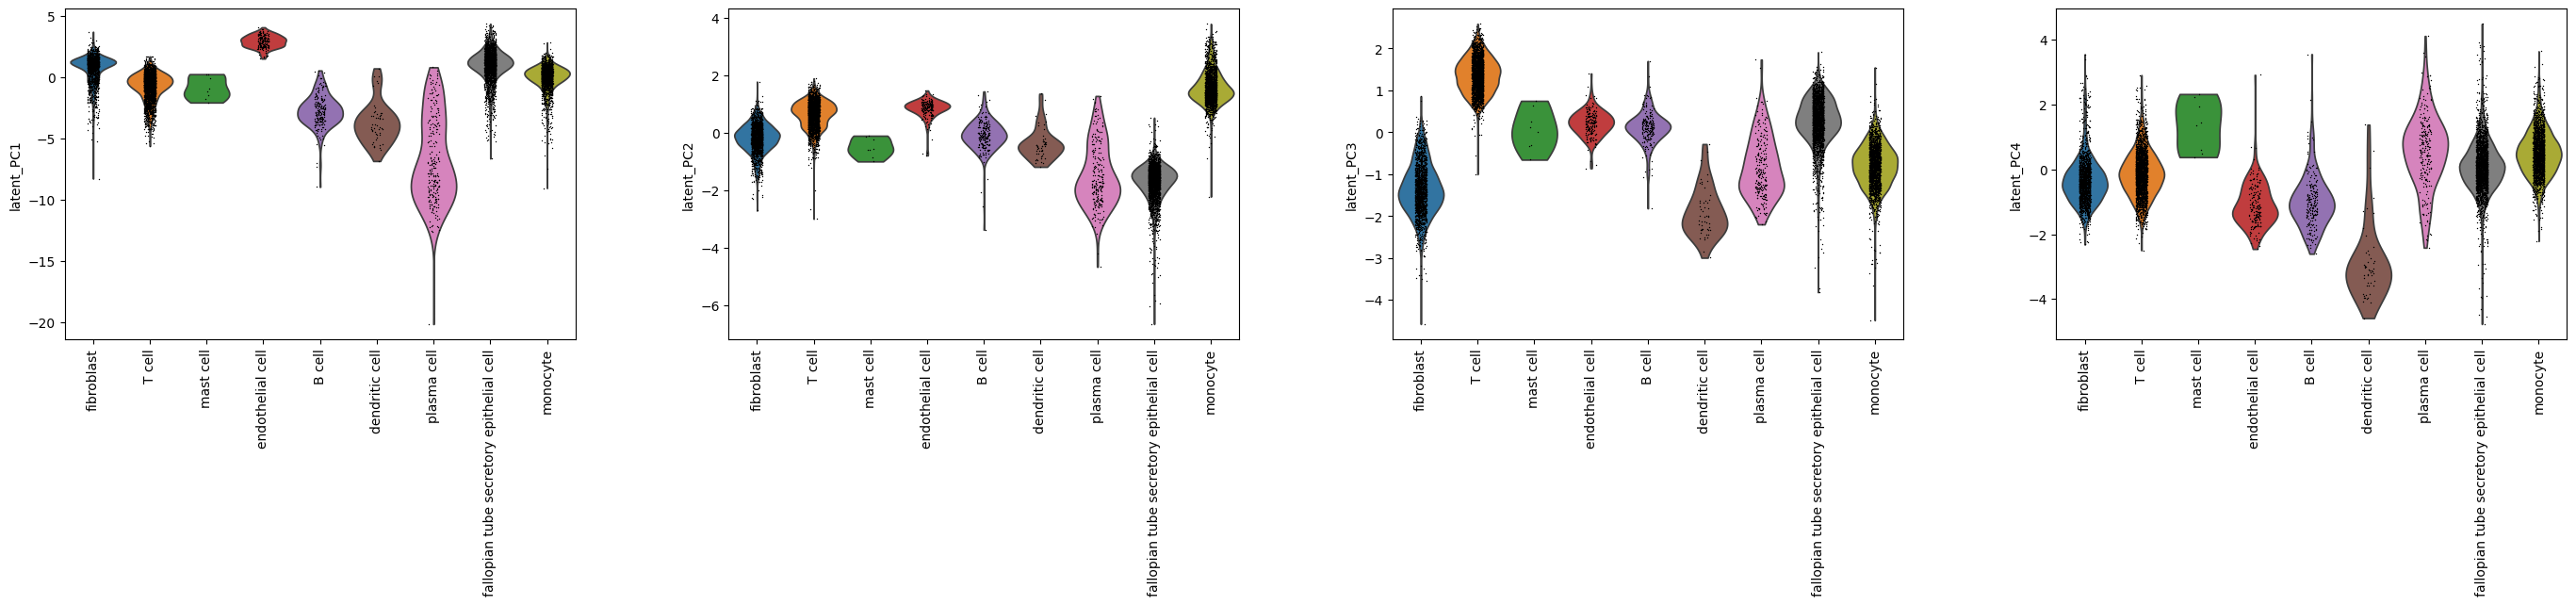

In [56]:
sc.pl.violin(
    adata,
    keys=["latent_PC1", "latent_PC2", "latent_PC3", "latent_PC4"],
    groupby="cell_type",   # or whatever your annotation is called
    rotation=90
)

In [56]:
from scipy.stats import spearmanr

X = adata.X.A if hasattr(adata.X, "A") else adata.X

pc_gene_corr = {}

for k, pc in enumerate(["latent_PC1", "latent_PC2", "latent_PC3", "latent_PC4"], start=1):
    scores = adata.obs[pc].values
    corrs = np.zeros(X.shape[1])

    for g in range(X.shape[1]):
        gene = X[:, g]

        # skip genes with no variance
        if np.std(gene) == 0:
            corrs[g] = 0.0
        else:
            corrs[g], _ = spearmanr(gene, scores)

    pc_gene_corr[f"PC{k}"] = corrs


In [57]:
ranked_genes = {}

for k in ["PC1", "PC2", "PC3", "PC4"]:
    r = pc_gene_corr[k]
    order = np.argsort(-r)
    ranked_genes[k] = pd.Series(r[order], index=adata.var_names[order])

In [60]:
ranked_genes["PC1"].isna().sum()

0

In [61]:
ranked_genes['PC1']

MDK         0.564113
IGFBP2      0.518490
CALD1       0.516584
COL18A1     0.511463
KCNQ1OT1    0.509371
              ...   
LTB        -0.421707
CYTIP      -0.429897
CD48       -0.435374
PTPRC      -0.442154
CD52       -0.504591
Length: 31815, dtype: float64

In [ ]:
# Question: Why do I have NAN values in some of my ranked genes' spearman correlations?

In [58]:
top_genes = {}

for pc in ["PC1", "PC2", "PC3"]:
    s = ranked_genes[pc]

    top_pos = s.head(10)        # most positively correlated
    top_neg = s.tail(10)        # most negatively correlated

    top_genes[pc] = {
        "positive": top_pos,
        "negative": top_neg
    }

    print(f"\n==== {pc} ====")
    print("Top positive:")
    print(top_pos)
    print("\nTop negative:")
    print(top_neg[::-1])



==== PC1 ====
Top positive:
MDK         0.564113
IGFBP2      0.518490
CALD1       0.516584
COL18A1     0.511463
KCNQ1OT1    0.509371
S100A13     0.504104
MT-ND1      0.502937
MT-ND4      0.499130
SERPINH1    0.492891
IFITM3      0.488972
dtype: float64

Top negative:
CD52    -0.504591
PTPRC   -0.442154
CD48    -0.435374
CYTIP   -0.429897
LTB     -0.421707
CD3D    -0.418690
CD2     -0.417434
CXCR4   -0.412702
CD37    -0.407082
TRAC    -0.398100
dtype: float64

==== PC2 ====
Top positive:
SRGN      0.783539
PTPRC     0.721086
LAPTM5    0.716211
TYROBP    0.704548
ITGB2     0.693470
FCER1G    0.682349
FYB1      0.670839
CD53      0.649265
LYZ       0.641194
FCGR3A    0.636368
dtype: float64

Top negative:
KRT18     -0.718236
WFDC2     -0.708679
KRT19     -0.704250
KRT8      -0.703419
EPCAM     -0.676683
CLDN3     -0.664325
SLPI      -0.652648
S100A13   -0.650651
CD24      -0.642513
KRT7      -0.631099
dtype: float64

==== PC3 ====
Top positive:
CD2      0.621257
CD3D     0.588787
CD3E   

**Note**
- Descriptions given for the genes below are not comprehensive and are summaries of information found on GeneCards

```
==== PC2 ====
Top positive:
SRGN      0.783539 - Formation of mast cell secretory granules. Storage of proteases in connective tissue, musosal mast cells and storage of granzyme B in T-lymphocytes. Localizes neutrophil elastase in azurophil granules of neutrophils. 
PTPRC     0.721086 - Cell growth, differentiation, mitosis, and oncogenic transformation. Regular of T- and B-cell antigen receptor signaling. 
LAPTM5    0.716211 - Encodes transmembrane receptor associated with lysosomes
TYROBP    0.704548 - Encodes transmembrane signaling polypeptide which contains immunoreceptor tyrosine-based activation motif (ITAM). May be associated with killer-cell inhibitory receptor (KIR) family of membrane glycoproteins. Putative receptor, "triggering receptor expressed on myeloid cells 2" 
ITGB2     0.693470 - Encodes integrin beta chain to form integrin heterodimers. Participates in cell adhesion and cell-surface mediated signalling. Plays important role in immune response. 
FCER1G    0.682349 - Mediates allergic inflammatory signaling in mast cells 
FYB1      0.670839 - Encodes protein that serves as an adapter for FYN protein and LCP2 signaling cascades in T-cells. Encoded protein involved in platlet activation and controls expression of interleukin-2. 
CD53      0.649265 - Encodes protein that is member of transmembrane 4 superfamily. Most members cell surface proteins that mediate signal tr4ansduction and play role in cell development activation, growth, and motility. Encoded protein is cell surface glycoprotein that is known to complex with integrins. Contributes to transduction of CD2-generated signals in T cells and nature killer cells and been suggested to play role in growth regulation. 
LYZ       0.641194 - Encodes lysozyme (has antibacterial activity against a number of bacterial species) 
FCGR3A    0.636368 - Encodes receptor for Fc portion of immunoglobulin G, responsible for removal of antigen-antibody complexes from circulation 
dtype: float64

Top negative:
KRT18     -0.718236 - Encodes type I intermediate filament chain keratin 18 
WFDC2     -0.708679 - Encodes protein that is member of WFDC domain family. WFDC domain functions as a protease inhibitor in many family members. Expressed in pulmonary epithelial cells and found to be expressed in **some ovarian cancers** (What kind of ovarian cancers)? 
KRT19     -0.704250 - Ecnodes protein that is member of keratin family (keratins are intermediate filament proteins responsible for structural integrity of epithelial cells). 
KRT8      -0.703419 - Member of type II keratin family. Type i and type II keratins heteropolymerize to form intermediate-sized filaments in cytoplasm of epithelial cells. Proteins plays role in maintaining cellcular structural integrity and functions in signal transduction and cellcular differentiation. 
EPCAM     -0.676683 - Carcinoma-associated antigen. Expressed on most normal epithelial cells and gastrointestinal carcinomas? 
CLDN3     -0.664325 - Represent one mode of cell-to-cell adhesion in epithelial or endothelial cell sheets forming continuous seals around cells and serving as a physical barrier to prevent solutes and water from passing freely through the paracellular space. Encoded protein is an integral membrane protein. 
SLPI      -0.652648 - Encodes secreted inhibitor which protects epithelial tissues from serine proteases
S100A13   -0.650651 - Encoded protein is member of S100 family of proteins containing 2 EF-hand calcium-binding motifs. Regulates cell cycle progression and differentiation. High expression in thyroid gland, smooth muscle cells. 
CD24      -0.642513 - Encodes sialoglycoprotein expressed on mature granulocytes and B cells. 
KRT7      -0.631099 - Encoded protein is member of kertain gene famil. Specifically expressed in simple epithelia lining cavities of internal organs and in gland ducts and blood vessels. 
dtype: float64
```




In [94]:
gene = "ITGB1"
gene_idx = adata.var_names.get_loc(gene)
expr = adata.X[:, gene_idx]

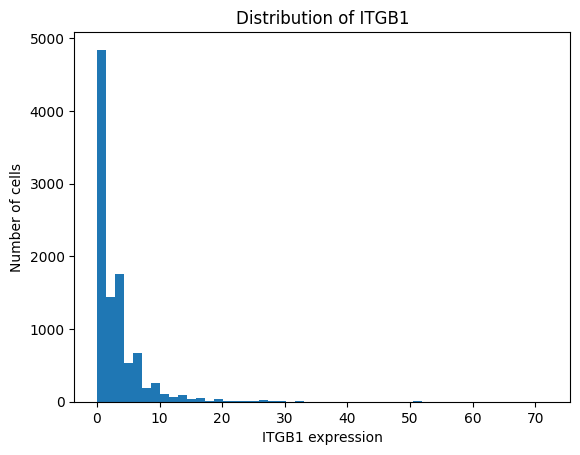

In [97]:
plt.hist(expr.todense(), bins=50)
plt.xlabel(f"{gene} expression")
plt.ylabel("Number of cells")
plt.title(f"Distribution of {gene}")
plt.show()

#### Pairwise Plots - 1 Sanity Check Against Sarah's Work

In [54]:
for cell_type in adata.obs["cell_type"].unique(): 
    print(cell_type)

T cell
fallopian tube secretory epithelial cell
fibroblast
monocyte
plasma cell
dendritic cell
endothelial cell
B cell
mast cell


In [55]:
mask_tcell = adata.obs["cell_type"] == "T cell"
mask_fallopian = adata.obs["cell_type"] == "fallopian tube secretory epithelial cell"
mask_fibroblast = adata.obs["cell_type"] == "fibroblast"
mask_monocyte = adata.obs["cell_type"] == "monocyte"
mask_plasma = adata.obs["cell_type"] == "plasma cell"
mask_dendritic = adata.obs["cell_type"] == "dendritic cell"
mask_endothelial = adata.obs["cell_type"] == "endothelial cell"
mask_bcell = adata.obs["cell_type"] == "B cell"
mask_mast = adata.obs["cell_type"] == "mast cell"

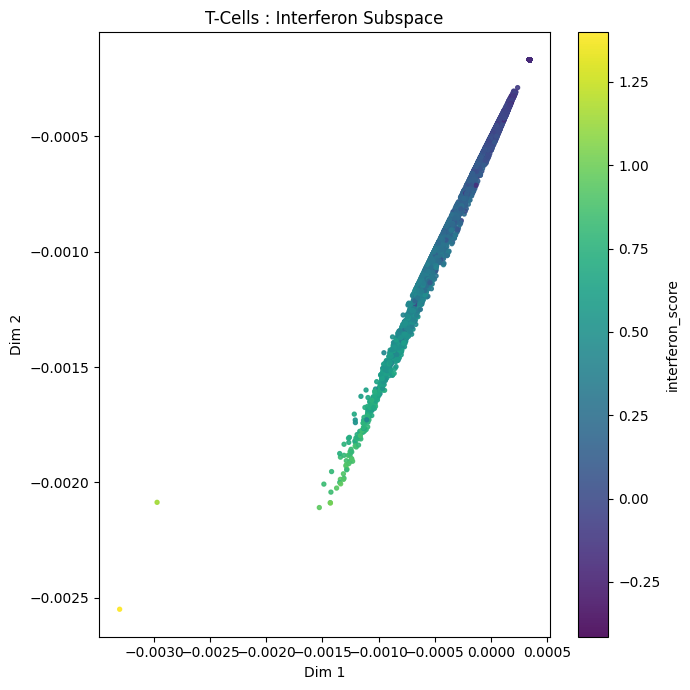

In [56]:
# T-cells
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_tcell],
    obs_values=adata.obs[desired_obs][mask_tcell],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "T-Cells : Interferon Subspace" 
)

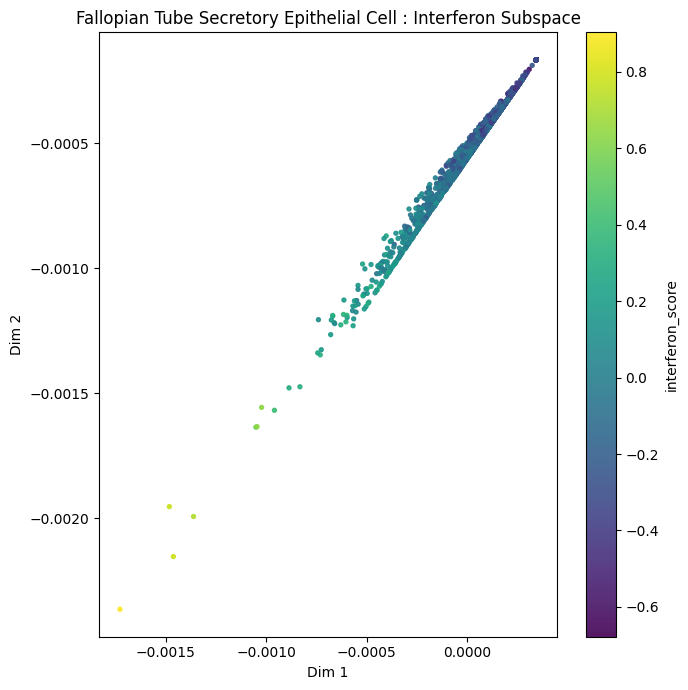

In [57]:
# Fallopian tube secretory epithelial cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_fallopian],
    obs_values=adata.obs[desired_obs][mask_fallopian],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Fallopian Tube Secretory Epithelial Cell : Interferon Subspace" 
)

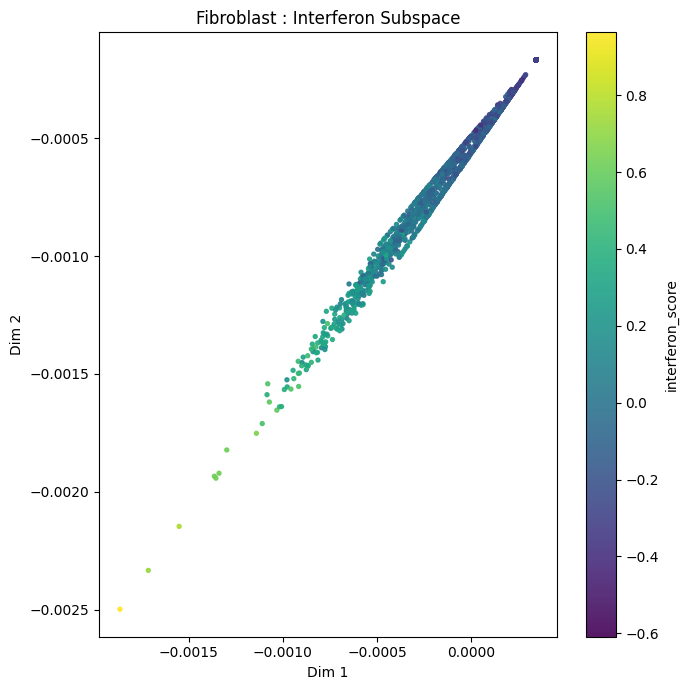

In [58]:
# Fibroblast 
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_fibroblast],
    obs_values=adata.obs[desired_obs][mask_fibroblast],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Fibroblast : Interferon Subspace" 
)

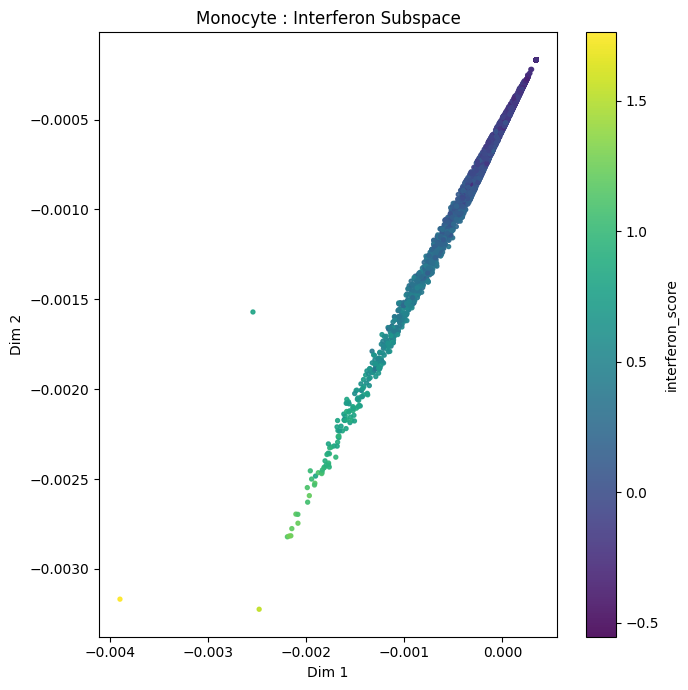

In [59]:
# Monocyte
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_monocyte],
    obs_values=adata.obs[desired_obs][mask_monocyte],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Monocyte : Interferon Subspace" 
)

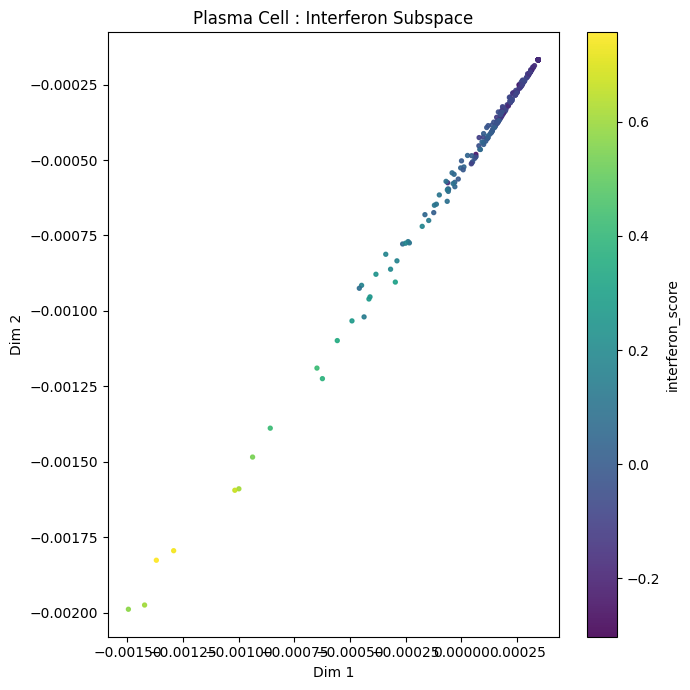

In [60]:
# Plasma cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_plasma],
    obs_values=adata.obs[desired_obs][mask_plasma],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Plasma Cell : Interferon Subspace" 
)

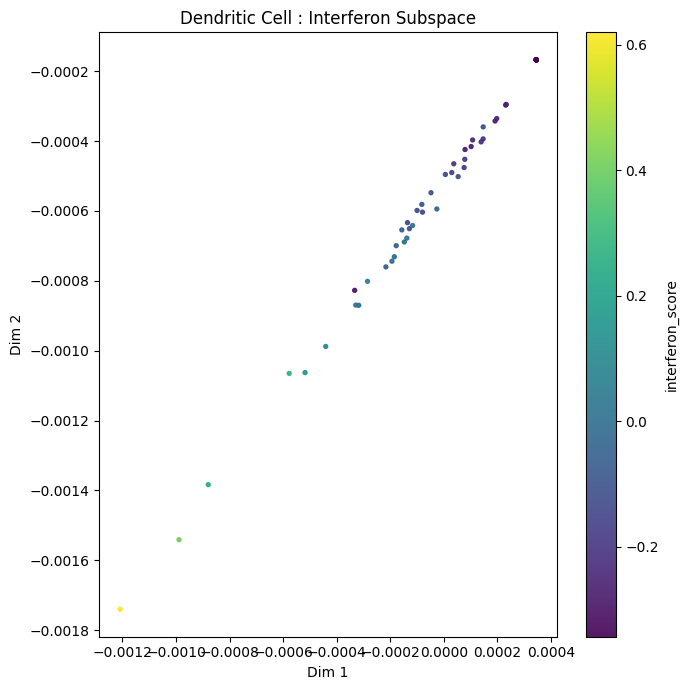

In [61]:
# Dendritic cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_dendritic],
    obs_values=adata.obs[desired_obs][mask_dendritic],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Dendritic Cell : Interferon Subspace" 
)

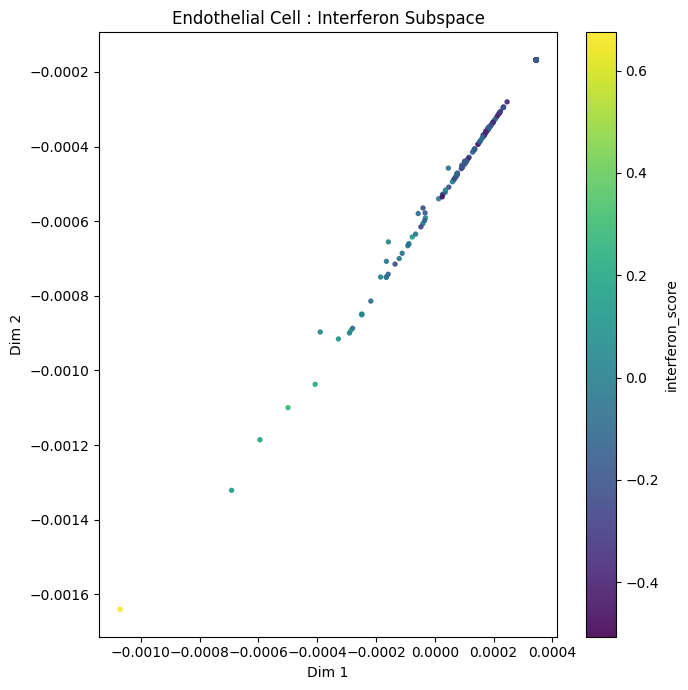

In [62]:
# Endothelial cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_endothelial],
    obs_values=adata.obs[desired_obs][mask_endothelial],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Endothelial Cell : Interferon Subspace" 
)

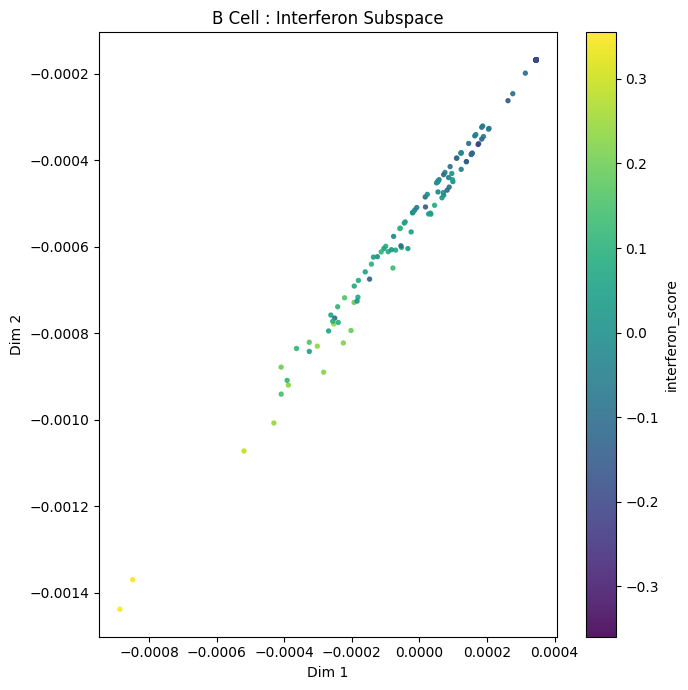

In [63]:
# B cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_bcell],
    obs_values=adata.obs[desired_obs][mask_bcell],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "B Cell : Interferon Subspace" 
)

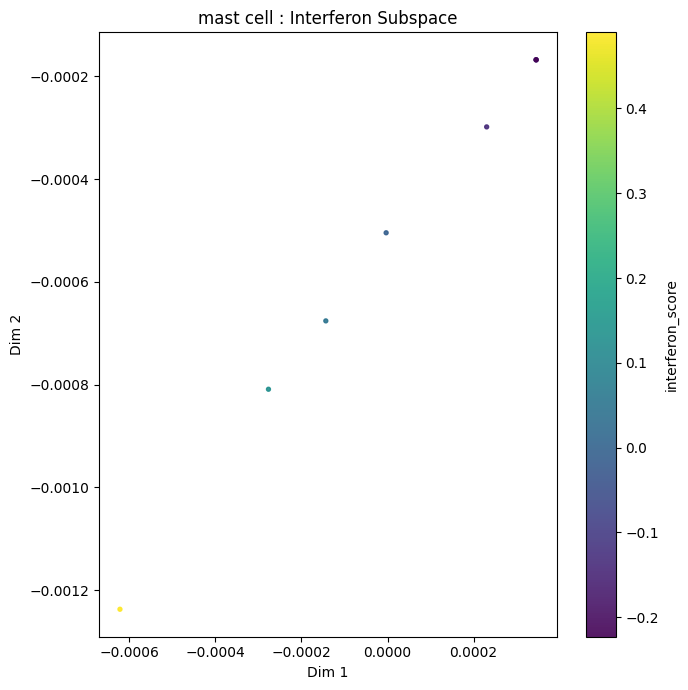

In [64]:
# mast cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_mast],
    obs_values=adata.obs[desired_obs][mask_mast],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "mast cell : Interferon Subspace" 
)

#### Pairwise Plots - 2 Dissociation Experiments

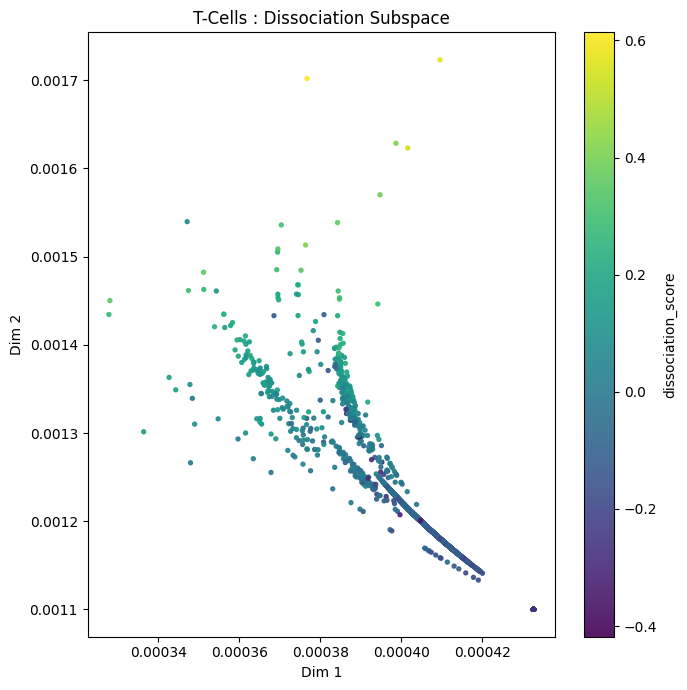

In [65]:
# T-cells
embeddings_key = "component3_e10"
desired_obs = 'dissociation_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_tcell],
    obs_values=adata.obs[desired_obs][mask_tcell],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "T-Cells : Dissociation Subspace" 
)

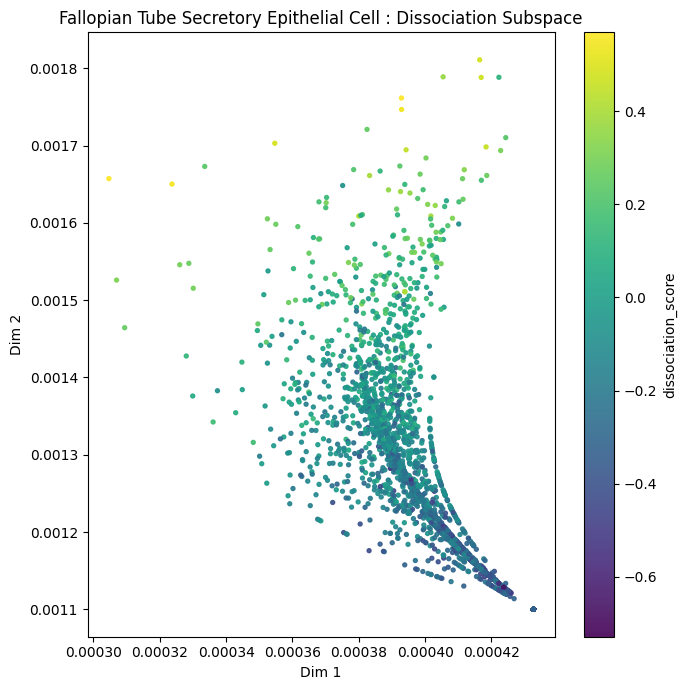

In [66]:
# Fallopian tube secretory epithelial cell
embeddings_key = "component3_e10"
desired_obs = 'dissociation_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_fallopian],
    obs_values=adata.obs[desired_obs][mask_fallopian],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Fallopian Tube Secretory Epithelial Cell : Dissociation Subspace" 
)

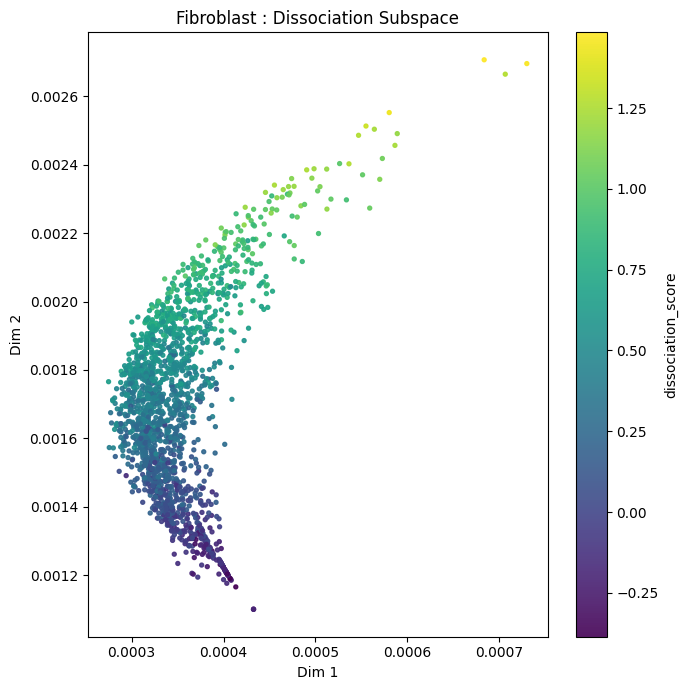

In [67]:
# Fibroblast 
embeddings_key = "component3_e10"
desired_obs = 'dissociation_score'
visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_fibroblast],
    obs_values=adata.obs[desired_obs][mask_fibroblast],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Fibroblast : Dissociation Subspace" 
)

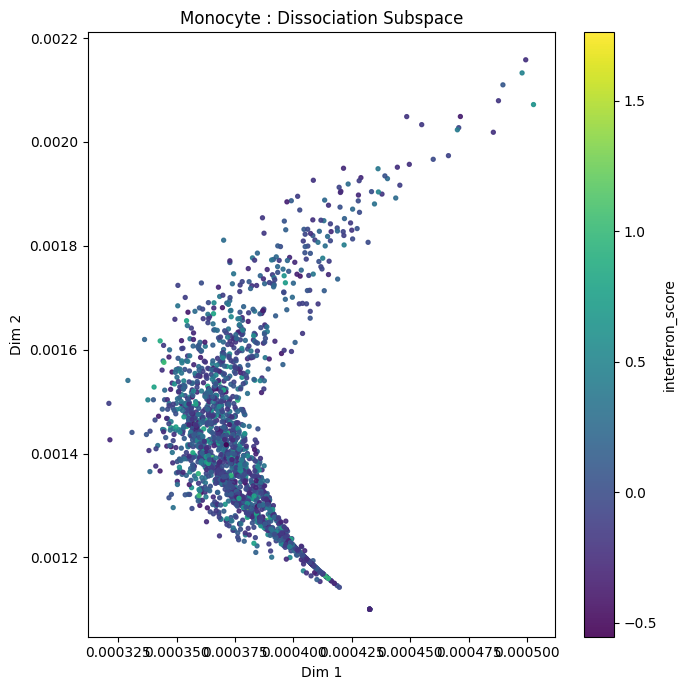

In [68]:
# Monocyte
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_monocyte],
    obs_values=adata.obs[desired_obs][mask_monocyte],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Monocyte : Dissociation Subspace" 
)

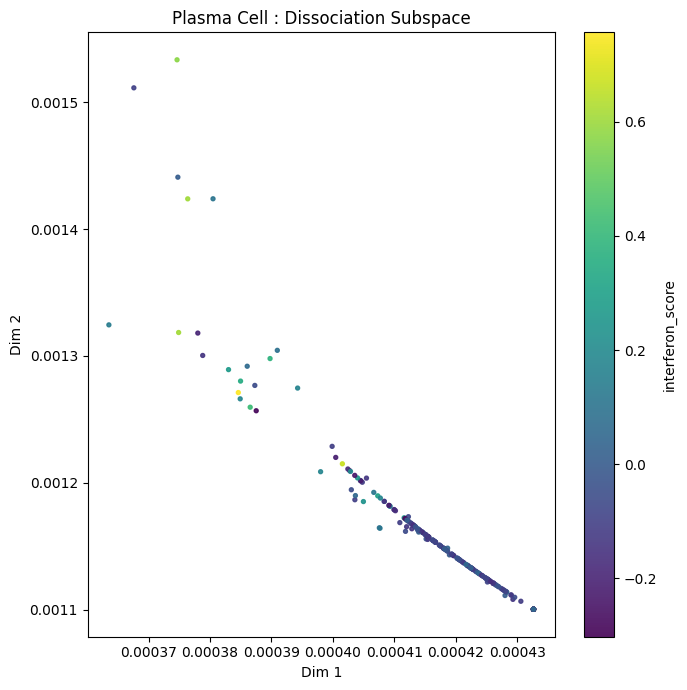

In [69]:
# Plasma cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_plasma],
    obs_values=adata.obs[desired_obs][mask_plasma],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Plasma Cell : Dissociation Subspace" 
)

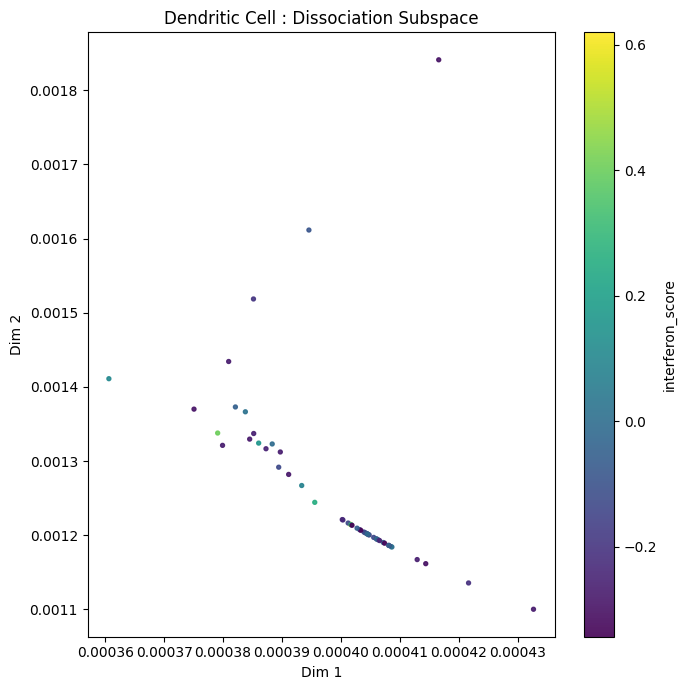

In [70]:
# Dendritic cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_dendritic],
    obs_values=adata.obs[desired_obs][mask_dendritic],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Dendritic Cell : Dissociation Subspace" 
)

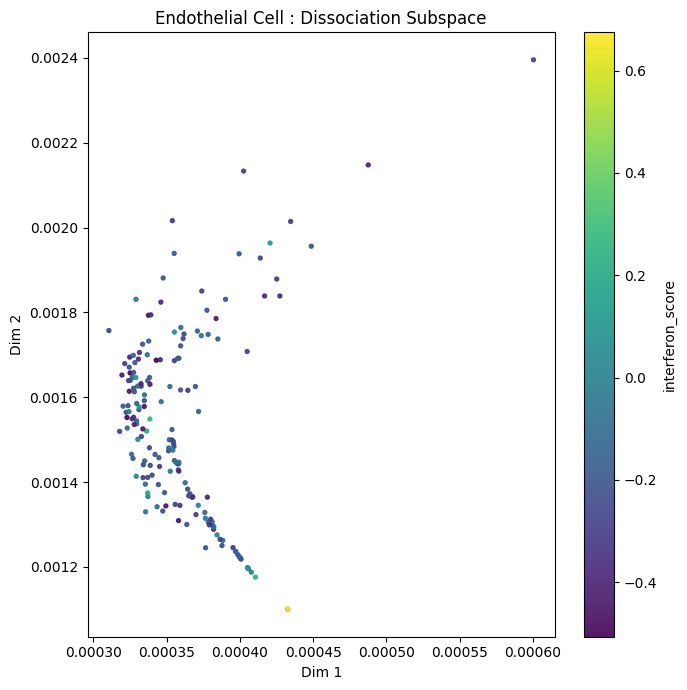

In [71]:
# Endothelial cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_endothelial],
    obs_values=adata.obs[desired_obs][mask_endothelial],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Endothelial Cell : Dissociation Subspace" 
)

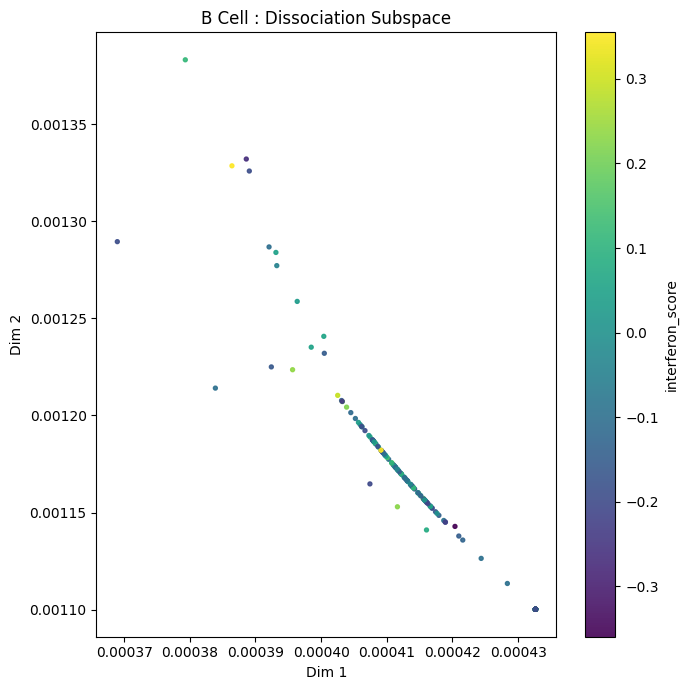

In [72]:
# B cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_bcell],
    obs_values=adata.obs[desired_obs][mask_bcell],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "B Cell : Dissociation Subspace" 
)

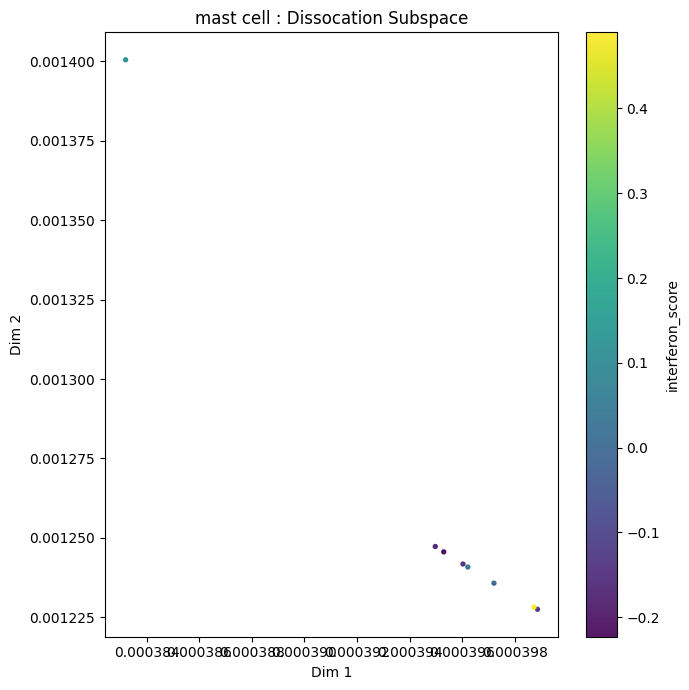

In [73]:
# mast cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_mast],
    obs_values=adata.obs[desired_obs][mask_mast],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "mast cell : Dissocation Subspace" 
)

In [67]:
adata.obs["cell_type"].unique()

cell_id
SPECTRUM-OV-070_S1_CD45P_ASCITES_CCGGTGAGTATGGAGC                                                   T cell
SPECTRUM-OV-037_S1_CD45N_LEFT_OVARY_GGGATCCTCATGCGGC              fallopian tube secretory epithelial cell
SPECTRUM-OV-054_S1_CD45P_INFRACOLIC_OMENTUM_TTGAACGTCCGCATAA                                        T cell
SPECTRUM-OV-041_S1_CD45N_RIGHT_FALLOPIAN_TUBE_TGTAAGCCACATACTG                                  fibroblast
SPECTRUM-OV-031_S1_CD45P_LEFT_FALLOPIAN_TUBE_CTCAAGAAGCACACAG                                       T cell
                                                                                    ...                   
SPECTRUM-OV-041_S1_CD45P_RIGHT_FALLOPIAN_TUBE_CTTGATTAGGCAGTCA                                      T cell
SPECTRUM-OV-054_S1_CD45N_INFRACOLIC_OMENTUM_CAGGGCTAGAGCCGAT                                    fibroblast
SPECTRUM-OV-082_S1_CD45N_BOWEL_GTCTTTAAGAAACTAC                   fallopian tube secretory epithelial cell
SPECTRUM-OV-009_S1_CD45P_RIGH

In [65]:
adata.obsm[embeddings_key]

array([[-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       ...,
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896]], shape=(10199, 10))

In [66]:
adata.obs[desired_obs]

cell_id
SPECTRUM-OV-070_S1_CD45P_ASCITES_CCGGTGAGTATGGAGC                -0.066753
SPECTRUM-OV-037_S1_CD45N_LEFT_OVARY_GGGATCCTCATGCGGC             -0.060493
SPECTRUM-OV-054_S1_CD45P_INFRACOLIC_OMENTUM_TTGAACGTCCGCATAA     -0.054439
SPECTRUM-OV-041_S1_CD45N_RIGHT_FALLOPIAN_TUBE_TGTAAGCCACATACTG   -0.080584
SPECTRUM-OV-031_S1_CD45P_LEFT_FALLOPIAN_TUBE_CTCAAGAAGCACACAG    -0.061362
                                                                    ...   
SPECTRUM-OV-041_S1_CD45P_RIGHT_FALLOPIAN_TUBE_CTTGATTAGGCAGTCA    0.003020
SPECTRUM-OV-054_S1_CD45N_INFRACOLIC_OMENTUM_CAGGGCTAGAGCCGAT     -0.224252
SPECTRUM-OV-082_S1_CD45N_BOWEL_GTCTTTAAGAAACTAC                  -0.173922
SPECTRUM-OV-009_S1_CD45P_RIGHT_OVARY_TCACTCGCATCTCGTC            -0.052288
SPECTRUM-OV-071_S1_CD45P_LEFT_OVARY_AGGCATTTCCGACAGC              0.029909
Name: G2M.Score, Length: 10199, dtype: float32

**QUESTIONS**
- Is using "everything else" to capture cell type really the best technique to use?
- Why does CellUntangler use the first latent subspace to reconstruct the genes that don't belong in the gene mask (when only the first latent subspace is used for reconstructing those genes that belong in the first gene mask)?
  A decision I need to might need to make (if the code doesn't already think about this and implement it)
  - Should all earlier subspaces contribute to the reconstruction of subsets of genes corresponding to later subspaces? Or, should only the last subset of genes (presumably corresponding to the largest number of genes) be reconstructed using the all latent subspaces up to the last subspace?
  - A sub-question: what guarantees disentanglement in models like CellUntangler?
  - Hmmm, if we stopped the gradient for all earlier subspaces when training later subspaces, would this ensure that earlier subspaces never "tweak" their parameters to get better at reconstructing a subset of genes unrelated to the subset of genes they should best reconstruct? 

What owu

**Worklist** 
- (HSSOC) Getting stuck on 2+ subspace CellUntangler (Get blocked on nuances of stopping gradients) 
- (Liver) Getting stuck on better benchmarking
- (Liver) Getting started on biological analysis of different dimensions + generating pairwise plots of disentangled dimensions 

**Ideas** 
- Might be useful to mix HGSOC dataset with non-cancerous cells to see how well the cell dissociation signal is captured in a particular latent space

**Deep Dives**
- What makes a "rotated" hyperbolic component "rotated"?
- How to visualize learnable curvatures in latent spaces? 